# Online Shoppers Purchasing Intention — Classification

**Problem.** Given how a visitor browsed an e-commerce site during a single
session, predict whether that session ended in a purchase.

This is a **binary classification** problem on tabular data. Six models are
trained on identical preprocessing and compared across six evaluation metrics.


## 1. Imports

All dependencies are declared here so the notebook runs top-to-bottom after a
kernel restart. These same packages are pinned in `requirements.txt` for
deployment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import joblib, os


## 2. Load the data

Each row is one browsing session. `Revenue` is the target: `True` if the
session ended in a purchase, `False` otherwise.

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")
print(df.shape)
print(df.dtypes)


(12330, 18)
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


## 3. Data quality checks

Four checks before any modelling:

- **Shape and dtypes** — 12,330 × 18 (17 features + target)
- **Missing values** — none, so no imputation is required
- **Class balance** — 84.53% / 15.47%, heavily imbalanced
- **Duplicates** — 125 rows

The imbalance is the single most important fact here: it makes accuracy a
misleading metric and drives the choice of AUC and MCC later.

The duplicate rows are all **zero-activity sessions** — no pages viewed, no
time on site, no purchase. They are retained rather than dropped, because they
record a genuine "bounced immediately" behaviour rather than a data error, and
represent only ~1% of the data.

**Dataset:** UCI Machine Learning Repository — Online Shoppers Purchasing
Intention Dataset (12,330 sessions, 17 features).


In [3]:
print(df["Revenue"].value_counts(normalize=True))
print(df.isna().sum())

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [4]:
df.groupby("Revenue")[["PageValues", "ExitRates", "ProductRelated", "BounceRates"]].mean()


,PageValues,ExitRates,ProductRelated,BounceRates
Revenue,,,,
False,1.975998,0.047378,28.714642,0.025317
True,27.264518,0.019555,48.210168,0.005117


In [5]:
print("Duplicate rows:", df.duplicated().sum())

df[df.duplicated(keep=False)].head(10)


Duplicate rows: 125


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
252,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,False,False
286,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False
293,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
298,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,8,1,Returning_Visitor,False,False
330,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,3,1,Returning_Visitor,False,False


## 4. Dataset summary

Stored as a variable so the identical description can be rendered in the
Streamlit app without duplicating text between notebook and app.

In [6]:
DATASET_INFO = """
**Online Shoppers Purchasing Intention Dataset**

- **Source:** UCI Machine Learning Repository (CC BY 4.0)
- **Rows:** 12,330 — each row is one browsing session on an e-commerce site
- **Features:** 17 (10 numeric, 6 categorical, 1 boolean)
- **Target:** `Revenue` — True if the session ended in a purchase

**Class balance:** 84.53% did not purchase, 15.47% did — imbalanced.

**Data quality**
- No missing values.
- 125 duplicate rows (201 rows involved). All are zero-activity
  sessions — no pages viewed, no time on site, no purchase.
  Retained, as they represent a genuine "bounced immediately"
  behaviour rather than a data error.

**Feature groups**
- *Behaviour:* page counts and time spent on Administrative,
  Informational and ProductRelated pages
- *Engagement:* BounceRates, ExitRates, PageValues
- *Timing:* Month, SpecialDay, Weekend
- *Visitor:* OperatingSystems, Browser, Region, TrafficType, VisitorType

**Strongest signal (mean by outcome)**

| Feature | Did not buy | Bought |
|---|---|---|
| PageValues | 1.98 | 27.27 |
| ExitRates | 0.047 | 0.020 |
| ProductRelated | 28.7 | 48.2 |
| BounceRates | 0.025 | 0.005 |

Note: four of the integer columns — OperatingSystems, Browser,
Region, TrafficType — are category codes, not quantities.
"""


## 5. Does behaviour separate buyers from non-buyers?

Comparing feature means across the two outcomes shows whether the data carries
usable signal. `PageValues` separates most sharply — buyers average roughly 14×
higher. Buyers also view more product pages and bounce and exit less.

All four differences point in the direction intuition predicts, which is a
sanity check that the data is behaving sensibly.


## 6. Grouping the columns by type

Different column types need different preprocessing, so they are grouped first.

Note that `OperatingSystems`, `Browser`, `Region` and `TrafficType` are stored
as integers but are **category codes, not quantities** — browser #13 is not
"more" than browser #2. Treating them as numeric would make a linear model
learn a meaningless ordering, so they are grouped with the categoricals.


In [7]:
numeric_features = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates",
    "PageValues", "SpecialDay",
]

categorical_features = [
    "Month", "VisitorType",
    "OperatingSystems", "Browser", "Region", "TrafficType",
]

boolean_features = ["Weekend"]

print(len(numeric_features), len(categorical_features), len(boolean_features))
print("total:", len(numeric_features) + len(categorical_features) + len(boolean_features))


10 6 1
total: 17


## 7. Train/test split

20% of sessions are held back for evaluation.

`stratify=y` preserves the 15.47% buyer rate in both halves — without it, the
two sets could carry different class balances and the scores would not be
comparable. `random_state=42` fixes the split so results are reproducible.


In [8]:


X = df.drop("Revenue", axis=1)
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("train:", X_train.shape, " test:", X_test.shape)
print("buyer rate — train:", round(y_train.mean(), 4), " test:", round(y_test.mean(), 4))


train: (9864, 17)  test: (2466, 17)
buyer rate — train: 0.1547  test: 0.1549


## 8. Preprocessing

A single `ColumnTransformer` handles all three column groups:

- **Numeric** → `StandardScaler`, because features span very different ranges
  (durations in thousands of seconds vs. rates between 0 and 1). Distance-based
  models such as kNN are otherwise dominated by the largest-scale column.
- **Categorical** → `OneHotEncoder`, giving each category its own 0/1 column so
  no false ordering is implied. `handle_unknown="ignore"` means unseen
  categories in uploaded data produce zeros instead of an error.
- **Boolean** → passthrough; already 0/1.

This expands 17 columns into 74.

Crucially, the preprocessor is fitted **inside a Pipeline**, so it learns its
scaling statistics from the training set only. Fitting on the full dataset
would leak test-set information into training and inflate every score.


In [9]:


preprocessor = ColumnTransformer(
    transformers=[
        ("num",  StandardScaler(),  numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bool", "passthrough",     boolean_features),
    ]
)

preprocessor.fit(X_train)
print(preprocessor.transform(X_train).shape)


(9864, 74)


Currently, the preprocessor and model are separate components. This is fragile because every prediction requires the preprocessing step to be applied first, using the same transformations and in the correct order.

A Pipeline combines both components into a single object. When .fit() is called, it applies the preprocessing and then trains the model. When .predict() is called, it automatically applies the same transformations before making a prediction. This creates a single, consistent object that can also be saved to disk and used directly by the application.

In [10]:
logreg = Pipeline([
    ("prep", preprocessor),
    ("clf",  LogisticRegression(max_iter=1000)),
])

logreg.fit(X_train, y_train)

print("accuracy:", round(logreg.score(X_test, y_test), 4))


accuracy: 0.8812


In [11]:

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

print("dummy accuracy:  ", round(dummy.score(X_test, y_test), 4))
print("logreg accuracy: ", round(logreg.score(X_test, y_test), 4))

dummy accuracy:   0.8451
logreg accuracy:  0.8812


In [12]:
pred = logreg.predict(X_test)
print(confusion_matrix(y_test, pred))
print("recall   :", round(recall_score(y_test, pred), 4))
print("precision:", round(precision_score(y_test, pred), 4))

[[2036   48]
 [ 245  137]]
recall   : 0.3586
precision: 0.7405


## 9. Evaluation function

One function returning all six required metrics, so every model is measured
identically.

`predict_proba` is used for AUC because AUC scores the model's *ranking* across
all thresholds, not its yes/no decisions at the default 0.5 cut-off.


In [13]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
)

def evaluate(name, model):
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, pred),
        "AUC":       roc_auc_score(y_test, proba),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred, zero_division=0),
        "F1":        f1_score(y_test, pred, zero_division=0),
        "MCC":       matthews_corrcoef(y_test, pred),
    }

evaluate("Logistic Regression", logreg)


{'Model': 'Logistic Regression',
 'Accuracy': 0.8811841038118411,
 'AUC': 0.8830367999517641,
 'Precision': 0.7405405405405405,
 'Recall': 0.3586387434554974,
 'F1': 0.48324514991181655,
 'MCC': 0.4609585723902892}

## 10. Models

The five required classifiers, plus a `DummyClassifier` baseline.

The dummy ignores every feature and always predicts the majority class. It is
included deliberately: on imbalanced data it scores ~84.5% accuracy while being
completely useless, which sets the floor any real model must clear.

`class_weight="balanced"` on Logistic Regression counteracts the imbalance by
weighting the minority class more heavily. `max_depth=5` on the Decision Tree
prevents it from growing to purity — an unrestricted tree memorises the
training data and returns only 0/1 probabilities, which destroys its AUC.

Every model runs through the identical preprocessor, so differences reflect the
algorithms rather than the preparation.



In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Dummy Classifier": DummyClassifier(strategy="most_frequent"),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth=5,  random_state=42),
    "k-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Gaussian Naive Bayes": GaussianNB(),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    results.append(evaluate(name, pipe))

pd.DataFrame(results).round(4)


,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8414,0.8931,0.4922,0.7435,0.5923,0.5152
1,Dummy Classifier,0.8451,0.5000,0.0000,0.0000,0.0000,0.0000
2,Decision Tree Classifier,0.8990,0.9172,0.7111,0.5864,0.6428,0.5883
3,k-Nearest Neighbours,0.8715,0.7572,0.6419,0.3848,0.4812,0.4307
4,Gaussian Naive Bayes,0.2733,0.7330,0.1727,0.9738,0.2934,0.1292
5,Random Forest Classifier,0.9011,0.9146,0.7828,0.5000,0.6102,0.5751


## 11. Saving models and test data

Each `.pkl` holds a **complete pipeline** — scaler, encoder and classifier
together. The Streamlit app loads these and calls `.predict()` directly, so
preprocessing replays exactly as it did in training and the app never retrains.

`test_data.csv` is the held-out 20%, saved for upload in the deployed app.


In [15]:

os.makedirs("model", exist_ok=True)

trained = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    trained[name] = pipe
    joblib.dump(pipe, f"model/{name.lower().replace(' ', '_')}.pkl")

print(os.listdir("model"))


['gaussian_naive_bayes.pkl', 'random_forest_classifier.pkl', 'logistic_regression.pkl', 'decision_tree_classifier.pkl', 'dummy_classifier.pkl', 'k-nearest_neighbours.pkl']


In [16]:
test_df = X_test.copy()
test_df["Revenue"] = y_test
test_df.to_csv("test_data.csv", index=False)
print(test_df.shape)


(2466, 18)


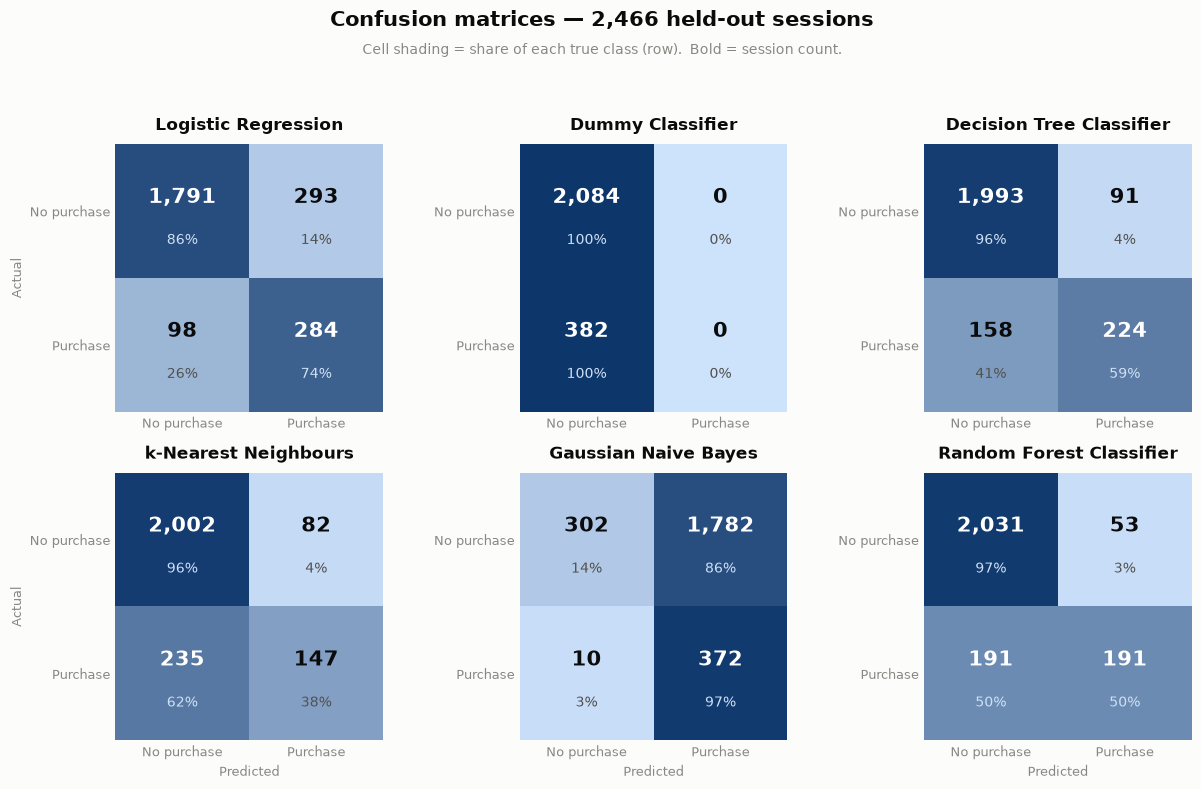

In [17]:
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix

SURFACE, INK, SECOND, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASE, BLUE = "#e1e0d9", "#c3c2b7", "#2a78d6"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#0d366b"])
LABELS = ["No purchase", "Purchase"]

fig, axes = plt.subplots(2, 3, figsize=(12.5, 8), facecolor=SURFACE)

for idx, (ax, (name, pipe)) in enumerate(zip(axes.ravel(), trained.items())):
    cm  = confusion_matrix(y_test, pipe.predict(X_test))
    cmn = cm / cm.sum(axis=1, keepdims=True)      # share of each TRUE class
    ax.set_facecolor(SURFACE)
    ax.imshow(cmn, cmap=SEQ, vmin=0, vmax=1)

    for i in range(2):
        for j in range(2):
            dark = cmn[i, j] > 0.42
            ax.text(j, i - 0.10, f"{cm[i, j]:,}", ha="center", va="center",
                    fontsize=15, fontweight="bold", color="#ffffff" if dark else INK)
            ax.text(j, i + 0.22, f"{cmn[i, j]:.0%}", ha="center", va="center",
                    fontsize=10, color="#cfe0f5" if dark else SECOND)

    ax.set_title(name, fontsize=12, fontweight="bold", color=INK, pad=10)
    ax.set_xticks([0, 1], LABELS, fontsize=9, color=MUTED)
    ax.set_yticks([0, 1], LABELS, fontsize=9, color=MUTED)
    if idx >= 3: ax.set_xlabel("Predicted", fontsize=9.5, color=MUTED)
    if idx % 3 == 0: ax.set_ylabel("Actual", fontsize=9.5, color=MUTED)
    for s in ax.spines.values(): s.set_visible(False)
    ax.tick_params(length=0)

fig.suptitle("Confusion matrices — 2,466 held-out sessions",
             fontsize=15, fontweight="bold", color=INK, y=0.98)
fig.text(0.5, 0.925, "Cell shading = share of each true class (row).  Bold = session count.",
         ha="center", fontsize=10, color=MUTED)
fig.tight_layout(rect=[0, 0, 1, 0.91])
fig.savefig("confusion_matrices.png", dpi=110, facecolor=SURFACE, bbox_inches="tight")
plt.show()


In [18]:
results_df = pd.DataFrame(results).round(4)
results_df.to_csv("model/results.csv", index=False)


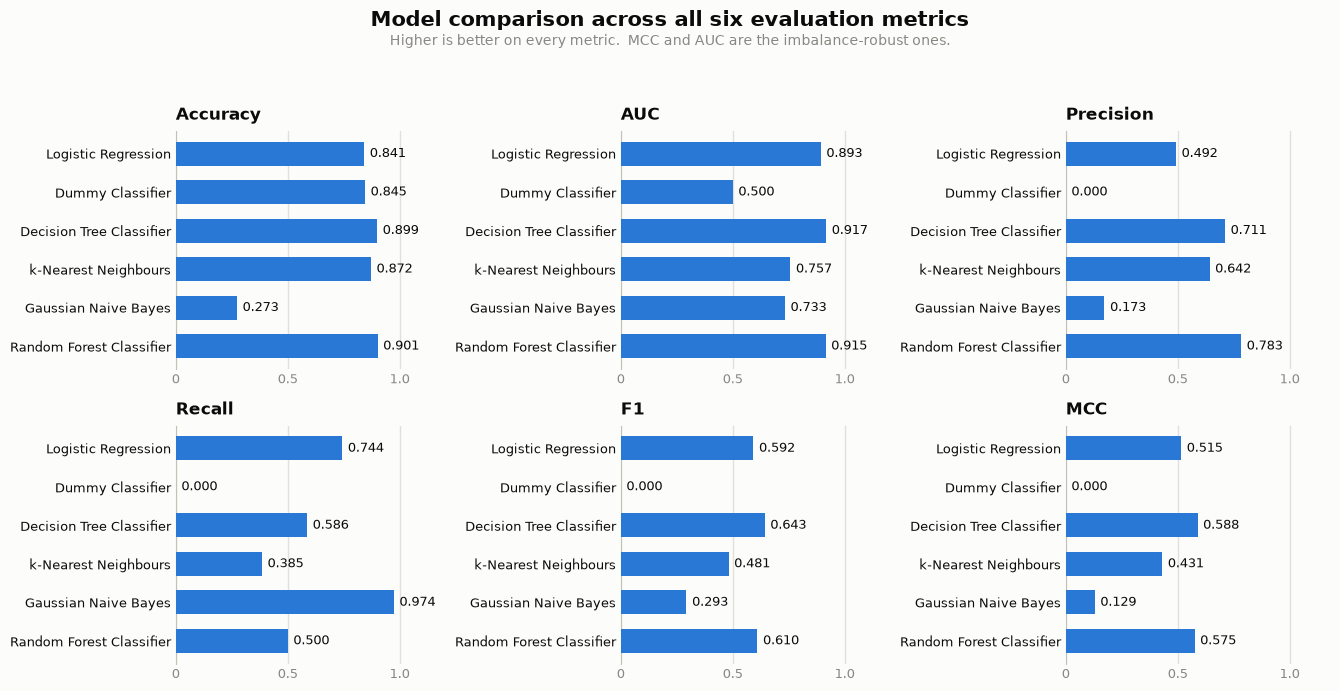

In [20]:
METRICS = ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]
order = results_df["Model"].tolist()[::-1]
ind   = results_df.set_index("Model")

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7), facecolor=SURFACE)

for ax, metric in zip(axes.ravel(), METRICS):
    vals = ind.loc[order, metric].values
    ax.set_facecolor(SURFACE)
    ax.barh(range(len(order)), vals, color=BLUE, height=0.62, zorder=3)
    for i, v in enumerate(vals):
        ax.text(v + 0.025, i, f"{v:.3f}", va="center", fontsize=9.5, color=INK, zorder=4)

    ax.set_xlim(0, 1.18)
    ax.set_yticks(range(len(order)), order, fontsize=9.5, color=INK)
    ax.set_xticks([0, 0.5, 1.0], ["0", "0.5", "1.0"], fontsize=9, color=MUTED)
    ax.set_title(metric, fontsize=12.5, fontweight="bold", color=INK, pad=8, loc="left")
    ax.xaxis.grid(True, color=GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for side in ["top", "right", "bottom"]: ax.spines[side].set_visible(False)
    ax.spines["left"].set_color(BASE)
    ax.tick_params(length=0)

fig.suptitle("Model comparison across all six evaluation metrics",
             fontsize=15, fontweight="bold", color=INK, y=0.98)
fig.text(0.5, 0.93, "Higher is better on every metric.  MCC and AUC are the imbalance-robust ones.",
         ha="center", fontsize=10, color=MUTED)
fig.tight_layout(rect=[0, 0, 1, 0.915])
fig.savefig("model_comparison.png", dpi=110, facecolor=SURFACE, bbox_inches="tight")
plt.show()


## 13. Observations

### Logistic Regression

`Acc 0.8414 · AUC 0.8931 · P 0.4922 · R 0.7435 · F1 0.5923 · MCC 0.5152`

Logistic Regression fits a linear decision boundary across the 74 encoded features. Its AUC of **0.8931** shows that the model is effective at ranking buyers above non-buyers. Using `class_weight="balanced"` gives more importance to the minority class, which represents only 15.47% of the dataset. This increases recall significantly from **0.3586 to 0.7435**, although precision decreases from **0.7405 to 0.4922**.

An important observation is that the model's accuracy of **0.8414 is slightly lower than the dummy baseline of 0.8451**. However, its MCC of **0.5152 compared with 0.0 for the dummy model** shows that accuracy alone does not provide an accurate picture of the model's predictive performance.

### Decision Tree (`max_depth=5`)

`Acc 0.8990 · AUC 0.9172 · P 0.7111 · R 0.5864 · F1 0.6428 · MCC 0.5883`

The Decision Tree is the **best overall performer**, achieving the highest MCC, F1-score and AUC. Unlike Logistic Regression, it can capture non-linear relationships between the features. For example, it can learn combinations such as high `PageValues` together with low `ExitRates`.

The `max_depth=5` constraint also helps prevent overfitting. The terminal nodes still contain a mixture of buyers and non-buyers, allowing `predict_proba` to generate graded probability estimates. In comparison, the unrestricted tree grows to depth 25 and produces mostly pure leaves, resulting in probabilities close to 0 or 1. This reduces its ability to rank observations effectively, causing its AUC to fall to **0.7340**.

### k-Nearest Neighbours (`k=5`)

`Acc 0.8715 · AUC 0.7572 · P 0.6419 · R 0.3848 · F1 0.4812 · MCC 0.4307`

k-Nearest Neighbours is one of the weaker genuine classifiers, particularly in terms of AUC. One-hot encoding increases the feature space from 17 original columns to 74 encoded features, with many of them being sparse binary variables. As the dimensionality increases, Euclidean distance becomes less informative, which is a typical example of the **curse of dimensionality**.

Class imbalance also affects the model. Since approximately 84.53% of sessions are non-buyers, the nearest neighbours of an actual buyer are often dominated by non-buyers. This helps explain the relatively low recall of **0.3848**.

### Gaussian Naive Bayes

`Acc 0.2733 · AUC 0.7330 · P 0.1727 · R 0.9738 · F1 0.2934 · MCC 0.1292`

Gaussian Naive Bayes produces one of the most interesting results among the models. Its accuracy of **0.2733** is far below the dummy baseline, while its recall of **0.9738** is the highest of all the models. This happens because the model predicts almost every session as a purchase, allowing it to capture nearly all actual buyers but also generating a very large number of false positives. This explains the very low precision of **0.1727**.

The model's assumptions also do not fit the dataset particularly well. The features are not conditionally independent; for example, `ProductRelated` and `ProductRelated_Duration` are naturally correlated. The numerical features are also not well described by Gaussian distributions because many of them are heavily right-skewed and zero-inflated. Most sessions contain zero informational pages and zero `PageValues`.

Its MCC of **0.1292** provides a more realistic assessment of its performance. Despite the extremely high recall, the model offers only limited overall predictive value.

### Random Forest

`Acc 0.9011 · AUC 0.9146 · P 0.7828 · R 0.5000 · F1 0.6102 · MCC 0.5751`

Random Forest achieves the **highest accuracy and precision** among the models. By averaging multiple decorrelated decision trees, it generally reduces the variance associated with an individual tree. Its precision of **0.7828** means that when the model predicts a purchase, it is correct nearly 78% of the time.

However, the model remains relatively conservative when identifying the minority class because it is used with default settings and without class weighting. As a result, recall is only **0.5000**, meaning that half of the actual buyers are missed.

Interestingly, Random Forest does not outperform the tuned single Decision Tree on MCC or F1-score. This suggests that the `max_depth=5` restriction on the single tree already acts as an effective regulariser, leaving less variance for the ensemble to reduce.

### Dummy Classifier (Baseline)

`Acc 0.8451 · AUC 0.5000 · P 0.0000 · R 0.0000 · F1 0.0000 · MCC 0.0000`

The Dummy Classifier ignores all input features and always predicts the majority class. It is included as a baseline to show what can be achieved without using any meaningful information from the dataset.

The model achieves **84.51% accuracy**, which may initially appear reasonable, but this is entirely driven by the class imbalance. Since it never predicts a purchase, precision, recall and F1-score are all zero. Its AUC of **0.5000** and MCC of **0.0000** confirm that it provides no useful predictive value.

---

## Overall Winner: Decision Tree (`max_depth=5`)

Overall, the **Decision Tree with `max_depth=5` is the strongest model** for this dataset. It performs best on the metrics that are more informative under class imbalance:

- **MCC:** 0.5883
- **F1-score:** 0.6428
- **AUC:** 0.9172

Random Forest performs slightly better in terms of accuracy (**0.9011**) and precision (**0.7828**), but accuracy is less informative when 84.53% of the observations belong to the same class. Its higher precision also comes at the cost of a recall of only **0.5000**, meaning that it fails to identify half of the actual buyers.

The Decision Tree also has a practical advantage because of its **interpretability**. Its splits and decision rules can be inspected directly and explained to a business audience, making the model easier to understand and justify.

---

## Why Accuracy Alone Is Misleading on This Dataset

The Dummy Classifier and Gaussian Naive Bayes demonstrate two opposite ways in which accuracy can be misleading:

| Model | Accuracy | Recall | MCC |
|---|---:|---:|---:|
| Dummy Classifier | 0.8451 | 0.0000 | 0.0000 |
| Gaussian Naive Bayes | 0.2733 | 0.9738 | 0.1292 |

The Dummy Classifier achieves high accuracy simply because it always predicts the majority class. Gaussian Naive Bayes behaves almost in the opposite way by predicting nearly every session as a purchase. This gives it extremely high recall but also results in a very large number of false positives.

When evaluated only on accuracy, the Dummy Classifier appears much stronger than Gaussian Naive Bayes. When evaluated only on recall, the ranking is completely reversed. In reality, neither model provides strong predictive performance. **MCC gives a more balanced assessment because it takes all four parts of the confusion matrix into account.**

This demonstrates why reporting **all six metrics — Accuracy, AUC, Precision, Recall, F1-score and MCC — provides a more complete evaluation of the models**, particularly for a dataset with substantial class imbalance.